**Bigger-font variant (2026-08 supervisor feedback item 2).** Copied from the original simple-plot notebook, not edited in place — same convention as `100_versions_pie_plot_simple_bigfont.ipynb` and the original-vs-simple-plot split before it. Reads from the bigfont chart source (`100_pie_charts_simple_bigfont/`) and writes to a separate `*_bigfont` post/output tree throughout, so nothing here collides with the existing simple-plot pilot data or its results. See `docs/SESSION_HANDOFF.md` for context.

---
# Gemma4-E4B
# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "tokenizers>=0.22.0,<=0.23.0",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Thu Aug 13 17:02:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:AF:00.0 Off |                    0 |
| N/A   31C    P0            127W /  700W |   15764MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# --- HF Auth ---
import sys
sys.path.append("/home/jovyan") 
from config_hf_token import HF_TOKEN
from huggingface_hub import login
login(token=HF_TOKEN)

# --- Path setup ---
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

# --- Load Gemma model ---
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/gemma-4-E4B-it"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
device = model.device

# --- Imports ---
from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_gemma import run_inference_gemma
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"        # experiments/e1/gemma4-12b/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample (reuses selected_images.json from Qwen runs) ---
correct_dir = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs"
incorrect_dir = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Found 100 images in /home/jovyan/conformity-llms-facebook-posts/spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs
✅ Saved selection to /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [4]:
from e1_utils.inference_gemma import run_inference_with_scores_gemma
from e1_utils.e1_optimized import (
    run_e1_baseline_logprobs, run_e1_metrics_logprobs,
    LIKE_CANDIDATES_SINGLE, LIKE_CANDIDATES_YESNO
)


In [5]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3
VRAM total: 84.9 GB
VRAM free: 15.9 GB reserved


In [6]:
for word in [" like", " scroll", " yes", " no"]:
    ids = processor.tokenizer(word, add_special_tokens=False).input_ids
    print(f"{word!r}: {ids} ({len(ids)} token{'s' if len(ids) != 1 else ''})")

' like': [1133] (1 token)
' scroll': [18098] (1 token)
' yes': [11262] (1 token)
' no': [951] (1 token)


In [7]:
print(OUTPUT_DIR)
print(correct_dir)
print(incorrect_dir)

/home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs
/home/jovyan/conformity-llms-facebook-posts/spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs
/home/jovyan/conformity-llms-facebook-posts/spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [8]:
import time
start = time.time()

# --- Baseline single (like/scroll) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json",
                inference_fn=run_inference_gemma)
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


✅ 001_correct → like
✅ 001_incorrect → like
✅ 002_correct → scroll
✅ 002_incorrect → scroll
✅ 003_correct → scroll
✅ 003_incorrect → scroll
✅ 004_correct → scroll
✅ 004_incorrect → scroll
✅ 005_correct → scroll
✅ 005_incorrect → scroll
✅ 006_correct → scroll
✅ 006_incorrect → scroll
✅ 007_correct → like
✅ 007_incorrect → scroll
✅ 008_correct → like
✅ 008_incorrect → scroll
✅ 009_correct → like
✅ 009_incorrect → scroll
✅ 010_correct → scroll
✅ 010_incorrect → scroll
✅ 011_correct → like
✅ 011_incorrect → scroll
✅ 012_correct → scroll
✅ 012_incorrect → scroll
✅ 013_correct → like
✅ 013_incorrect → like
✅ 014_correct → scroll
✅ 014_incorrect → scroll
✅ 015_correct → scroll
✅ 015_incorrect → scroll
✅ 016_correct → scroll
✅ 016_incorrect → scroll
✅ 017_correct → scroll
✅ 017_incorrect → scroll
✅ 018_correct → like
✅ 018_incorrect → like
✅ 019_correct → scroll
✅ 019_incorrect → scroll
✅ 020_correct → like
✅ 020_incorrect → like
✅ 021_correct → like
✅ 021_incorrect → like
✅ 022_correct → scro

In [9]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_baseline_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct → like {'like': {'logprob': -17.17552947998047, 'prob_forced_choice': 0.999999086745198}, 'scroll': {'logprob': -31.08177947998047, 'prob_forced_choice': 9.132548018955538e-07}}
✅ 001_incorrect → like {'like': {'logprob': -19.036869049072266, 'prob_forced_choice': 0.9997346976231016}, 'scroll': {'logprob': -27.271244049072266, 'prob_forced_choice': 0.0002653023768982879}}
✅ 002_correct → scroll {'like': {'logprob': -22.845930099487305, 'prob_forced_choice': 0.2689414213699951}, 'scroll': {'logprob': -21.845930099487305, 'prob_forced_choice': 0.7310585786300049}}
✅ 002_incorrect → scroll {'like': {'logprob': -24.16048240661621, 'prob_forced_choice': 0.007121428745735101}, 'scroll': {'logprob': -19.22298240661621, 'prob_forced_choice': 0.9928785712542649}}
✅ 003_correct → scroll {'like': {'logprob': -25.40995216369629, 'prob_forced_choice': 0.001187905494116342}, 'scroll': {'logprob': -18.67557716369629, 'prob_forced_choice': 0.9988120945058837}}
✅ 003_incorrect → scroll {'

In [10]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,22.5
1,like_rate_correct_%,28.0
2,like_rate_incorrect_%,17.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,002_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
196,099_correct,correct,You are shown a social media post.\nYou can ei...,scroll
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
198,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [11]:
import time
start = time.time()


# --- Baseline single (yes/no) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",
                inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


✅ 001_correct → no
✅ 001_incorrect → no
✅ 002_correct → no
✅ 002_incorrect → no
✅ 003_correct → no
✅ 003_incorrect → no
✅ 004_correct → no
✅ 004_incorrect → no
✅ 005_correct → no
✅ 005_incorrect → no
✅ 006_correct → no
✅ 006_incorrect → no
✅ 007_correct → no
✅ 007_incorrect → no
✅ 008_correct → no
✅ 008_incorrect → no
✅ 009_correct → no
✅ 009_incorrect → no
✅ 010_correct → no
✅ 010_incorrect → no
✅ 011_correct → no
✅ 011_incorrect → no
✅ 012_correct → no
✅ 012_incorrect → no
✅ 013_correct → no
✅ 013_incorrect → no
✅ 014_correct → no
✅ 014_incorrect → no
✅ 015_correct → no
✅ 015_incorrect → no
✅ 016_correct → no
✅ 016_incorrect → no
✅ 017_correct → no
✅ 017_incorrect → no
✅ 018_correct → no
✅ 018_incorrect → no
✅ 019_correct → no
✅ 019_incorrect → no
✅ 020_correct → no
✅ 020_incorrect → no
✅ 021_correct → no
✅ 021_incorrect → no
✅ 022_correct → no
✅ 022_incorrect → no
✅ 023_correct → no
✅ 023_incorrect → no
✅ 024_correct → no
✅ 024_incorrect → no
✅ 025_correct → no
✅ 025_incorrect → no


In [12]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
              output_filename="e1_results_baseline_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct → no {'yes': {'logprob': -36.779754638671875, 'prob_forced_choice': 8.233248585221221e-08}, 'no': {'logprob': -20.467254638671875, 'prob_forced_choice': 0.9999999176675142}}
✅ 001_incorrect → no {'yes': {'logprob': -40.944217681884766, 'prob_forced_choice': 1.876705305632167e-09}, 'no': {'logprob': -20.8504695892334, 'prob_forced_choice': 0.9999999981232948}}
✅ 002_correct → no {'yes': {'logprob': -44.752479553222656, 'prob_forced_choice': 6.903986662315424e-10}, 'no': {'logprob': -23.658727645874023, 'prob_forced_choice': 0.9999999993096014}}
✅ 002_incorrect → no {'yes': {'logprob': -44.4403076171875, 'prob_forced_choice': 1.0693124115404517e-09}, 'no': {'logprob': -23.7840576171875, 'prob_forced_choice': 0.9999999989306876}}
✅ 003_correct → no {'yes': {'logprob': -43.87617492675781, 'prob_forced_choice': 1.0364111505378747e-09}, 'no': {'logprob': -23.18867301940918, 'prob_forced_choice': 0.9999999989635888}}
✅ 003_incorrect → no {'yes': {'logprob': -44.18900680541992, '

In [13]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,002_correct,correct,You are shown a social media post.\nYou can ei...,no
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,003_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
196,099_correct,correct,You are shown a social media post.\nYou can ei...,no
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
198,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [14]:
import time
start = time.time()


# --- Baseline paired A/B ---
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
                       prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json",
                       inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


✅ Pair 001 → liked correct (answered A)
✅ Pair 002 → liked correct (answered A)
✅ Pair 003 → liked correct (answered A)
✅ Pair 004 → liked incorrect (answered A)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked incorrect (answered A)
✅ Pair 007 → liked correct (answered A)
✅ Pair 008 → liked correct (answered A)
✅ Pair 009 → liked correct (answered A)
✅ Pair 010 → liked incorrect (answered A)
✅ Pair 011 → liked incorrect (answered A)
✅ Pair 012 → liked incorrect (answered A)
✅ Pair 013 → liked correct (answered A)
✅ Pair 014 → liked incorrect (answered A)
✅ Pair 015 → liked correct (answered A)
✅ Pair 016 → liked incorrect (answered A)
✅ Pair 017 → liked correct (answered A)
✅ Pair 018 → liked correct (answered A)
✅ Pair 019 → liked correct (answered A)
✅ Pair 020 → liked incorrect (answered A)
✅ Pair 021 → liked correct (answered A)
✅ Pair 022 → liked correct (answered A)
✅ Pair 023 → liked incorrect (answered B)
✅ Pair 024 → liked correct (answered A)
✅ Pair 025 → liked cor

In [15]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,55.0
1,liked_incorrect_%,45.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,002,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
3,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
4,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
...,...,...,...,...,...,...
95,096,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
96,097,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
97,098,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
98,099,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [16]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

In [17]:
#correct_base_likes = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"
#incorrect_base_likes = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"

## Approach 1: like or scroll - single image

In [18]:
'''

import time
start = time.time()


# --- Likes only single (like/scroll) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json",
              inference_fn=run_inference_gemma)




end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\n\nimport time\nstart = time.time()\n\n\n# --- Likes only single (like/scroll) ---\nrun_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,\n              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json",\n              inference_fn=run_inference_gemma)\n\n\n\n\nend = time.time()\nelapsed = end - start\nhours = int(elapsed // 3600)\nminutes = int((elapsed % 3600) // 60)\nseconds = int(elapsed % 60)\nprint(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")\nprint(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")\n'

In [19]:
'''
run_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_logprobs.json", score_fn=run_inference_with_scores_gemma)
'''

'\nrun_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,\n               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,\n               output_filename="e1_results_likes_only_logprobs.json", score_fn=run_inference_with_scores_gemma)\n'

In [20]:
# metrics like/scroll
#analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")

## Approach 1: YES/NO variant

In [21]:
'''
import time
start = time.time()


# --- Likes only single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json",
              inference_fn=run_inference_gemma)


end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\nimport time\nstart = time.time()\n\n\n# --- Likes only single (yes/no) ---\nrun_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,\n              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json",\n              inference_fn=run_inference_gemma)\n\n\nend = time.time()\nelapsed = end - start\nhours = int(elapsed // 3600)\nminutes = int((elapsed % 3600) // 60)\nseconds = int(elapsed % 60)\nprint(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")\nprint(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")\n'

In [22]:
'''
run_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)
'''

'\nrun_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,\n               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,\n               output_filename="e1_results_likes_only_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)\n'

In [23]:
# metrics yes/no
#analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")

## Approach 2: A/B testing - paired images

In [24]:
''''
import time
start = time.time()

# --- Likes only paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\'\nimport time\nstart = time.time()\n\n# --- Likes only paired A/B ---\nrun_e1_metrics_paired(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR, SEED,\n                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",\n                      inference_fn=run_inference_gemma,\n                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",\n                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")\n\nend = time.time()\nelapsed = end - start\nhours = int(elapsed // 3600)\nminutes = int((elapsed % 3600) // 60)\nseconds = int(elapsed % 60)\nprint(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")\nprint(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")\n'

In [25]:
'''
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\nhours = int(elapsed // 3600)\nminutes = int((elapsed % 3600) // 60)\nseconds = int(elapsed % 60)\nprint(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")\nprint(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")\n'

In [26]:
#analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")

# Metrics - single image - like/scroll

In [27]:
# --- Metrics single (like/scroll) ---
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"


import time
start = time.time()


run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",
              inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")












✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 002_correct_10 → like
✅ 002_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 008_correct_10 → like
✅ 008_incorrect_10 → like
✅ 009_correct_10 → like
✅ 009_incorrect_10 → like
✅ 010_correct_10 → like
✅ 010_incorrect_10 → like
✅ 011_correct_10 → like
✅ 011_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 013_correct_10 → like
✅ 013_incorrect_10 → like
✅ 014_correct_10 → scroll
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 016_correct_10 → scroll
✅ 016_incorrect_10 → scroll
✅ 017_correct_10 → scroll
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 019_correct_10 → like
✅ 019_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrec

In [28]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_metrics_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → like {'like': {'logprob': -21.832658767700195, 'prob_forced_choice': 0.9999964991389082}, 'scroll': {'logprob': -34.39515686035156, 'prob_forced_choice': 3.5008610917343143e-06}}
✅ 001_incorrect_10 → like {'like': {'logprob': -22.03676414489746, 'prob_forced_choice': 0.9998012844663927}, 'scroll': {'logprob': -30.56020164489746, 'prob_forced_choice': 0.00019871553360735275}}
✅ 002_correct_10 → like {'like': {'logprob': -21.033613204956055, 'prob_forced_choice': 0.9999913353633785}, 'scroll': {'logprob': -32.68986511230469, 'prob_forced_choice': 8.664636621555543e-06}}
✅ 002_incorrect_10 → like {'like': {'logprob': -21.773488998413086, 'prob_forced_choice': 0.9988796226776031}, 'scroll': {'logprob': -28.566457748413086, 'prob_forced_choice': 0.0011203773223969365}}
✅ 003_correct_10 → like {'like': {'logprob': -21.90647315979004, 'prob_forced_choice': 0.9999501404178727}, 'scroll': {'logprob': -31.81272315979004, 'prob_forced_choice': 4.985958212727021e-05}}
✅ 003_inco

In [29]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,90.58
1,like_rate_correct_%,92.50
2,like_rate_incorrect_%,88.67


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,85.0,90.0,80.0
1,100,200.0,84.5,86.0,83.0
2,1000,200.0,89.0,90.0,88.0
3,10000,200.0,93.0,94.0,92.0
4,100000,200.0,95.5,97.0,94.0
5,1000000,200.0,96.5,98.0,95.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [30]:
import time
start = time.time()


# --- Metrics single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",
              inference_fn=run_inference_gemma)





end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 002_correct_10 → no
✅ 002_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → no
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → no
✅ 007_incorrect_10 → no
✅ 008_correct_10 → no
✅ 008_incorrect_10 → no
✅ 009_correct_10 → no
✅ 009_incorrect_10 → no
✅ 010_correct_10 → no
✅ 010_incorrect_10 → no
✅ 011_correct_10 → no
✅ 011_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 013_correct_10 → no
✅ 013_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → no
✅ 015_incorrect_10 → no
✅ 016_correct_10 → no
✅ 016_incorrect_10 → no
✅ 017_correct_10 → no
✅ 017_incorrect_10 → no
✅ 018_correct_10 → no
✅ 018_incorrect_10 → no
✅ 019_correct_10 → no
✅ 019_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 022_correct_10 → no
✅ 022_incorr

In [31]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_metrics_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → no {'yes': {'logprob': -42.132606506347656, 'prob_forced_choice': 6.153479770471597e-09}, 'no': {'logprob': -23.22635841369629, 'prob_forced_choice': 0.9999999938465203}}
✅ 001_incorrect_10 → no {'yes': {'logprob': -44.0021858215332, 'prob_forced_choice': 5.7236278091299e-10}, 'no': {'logprob': -22.720937728881836, 'prob_forced_choice': 0.9999999994276372}}
✅ 002_correct_10 → no {'yes': {'logprob': -41.25593185424805, 'prob_forced_choice': 3.617437250685528e-09}, 'no': {'logprob': -21.818431854248047, 'prob_forced_choice': 0.9999999963825628}}
✅ 002_incorrect_10 → no {'yes': {'logprob': -42.75408172607422, 'prob_forced_choice': 1.289836976596949e-09}, 'no': {'logprob': -22.28533172607422, 'prob_forced_choice': 0.9999999987101631}}
✅ 003_correct_10 → no {'yes': {'logprob': -44.064430236816406, 'prob_forced_choice': 1.174409931818177e-09}, 'no': {'logprob': -23.501930236816406, 'prob_forced_choice': 0.9999999988255901}}
✅ 003_incorrect_10 → no {'yes': {'logprob': -44.1

In [32]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,0.0,0.0,0.0
1,100,200.0,0.0,0.0,0.0
2,1000,200.0,0.0,0.0,0.0
3,10000,200.0,0.0,0.0,0.0
4,100000,200.0,0.0,0.0,0.0
5,1000000,200.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,no
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [33]:
import time
start = time.time()

# --- Metrics paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 002_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 008_correct0_vs_incorrect0 → liked correct (answered A)
✅ 009_correct0_vs_incorrect0 → liked correct (answered A)
✅ 010_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 011_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 013_correct0_vs_incorrect0 → liked correct (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 016_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)


In [34]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



⏱ Total runtime: 0h 20m 19s
⏱ Average per pair: 0.25s


In [35]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.29
1,overall_liked_incorrect_%,49.71
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,55.0,45.0,0.0
1,0_vs_10,100.0,1.0,99.0,0.0
2,0_vs_100,100.0,0.0,100.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,0.0,100.0,0.0
6,0_vs_1000000,100.0,0.0,100.0,0.0
7,10_vs_0,100.0,100.0,0.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_metrics_paired.csv


# Metrics — correct vs. correct paired A/B (comparison 1)

Added 2026-07-16 per supervisor feedback (`docs/SESSION_HANDOFF.md`). Pairs the correct-claim variant of the same post against itself at two different engagement scales, isolating the pure engagement-preference effect with content held constant — comparison 1 of the two-comparison design (comparison 2 is the correct-vs-incorrect cell above, already run). Reuses the same rendered images, no new assets needed.

In [36]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (comparison 1, metrics/realistic) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_correct_vs_correct_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 002_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 003_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 004_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 005_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 006_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 007_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 008_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 009_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 010_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 011_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 012_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 013_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 014_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 015_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 016_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 017_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 018_correct0_vs_correct0 → liked scale 0 (answ

# LIKES ONLY NOISE

In [37]:
correct_base_noise = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
incorrect_base_noise = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only_noise"

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only_noise.json",
              inference_fn=run_inference_gemma)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_noise_logprobs.json", score_fn=run_inference_with_scores_gemma)

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_noise_yesno.json",
              inference_fn=run_inference_gemma)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_noise_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)

✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 002_correct_10 → like
✅ 002_incorrect_10 → like
✅ 003_correct_10 → scroll
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → scroll
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → scroll
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 008_correct_10 → like
✅ 008_incorrect_10 → like
✅ 009_correct_10 → like
✅ 009_incorrect_10 → like
✅ 010_correct_10 → like
✅ 010_incorrect_10 → like
✅ 011_correct_10 → like
✅ 011_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 013_correct_10 → like
✅ 013_incorrect_10 → like
✅ 014_correct_10 → scroll
✅ 014_incorrect_10 → scroll
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 016_correct_10 → scroll
✅ 016_incorrect_10 → like
✅ 017_correct_10 → scroll
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 019_correct_10 → like
✅ 019_incorrect_10 → like
✅ 020_correct_10 → scroll
✅ 

# Likes only with noise A/B testing


In [38]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 002_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 008_correct0_vs_incorrect0 → liked correct (answered A)
✅ 009_correct0_vs_incorrect0 → liked correct (answered A)
✅ 010_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 011_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 013_correct0_vs_incorrect0 → liked correct (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 016_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)


In [39]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 20m 1s
⏱ Average per pair: 0.25s


In [40]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.55
1,overall_liked_incorrect_%,49.45
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,55.0,45.0,0.0
1,0_vs_10,100.0,1.0,99.0,0.0
2,0_vs_100,100.0,0.0,100.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,0.0,100.0,0.0
6,0_vs_1000000,100.0,0.0,100.0,0.0
7,10_vs_0,100.0,100.0,0.0,0.0
8,10_vs_10,100.0,54.0,46.0,0.0
9,10_vs_100,100.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_analysis_likes_only_noise_paired.csv


In [41]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (likes_only_noise) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_correct_vs_correct_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 002_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 003_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 004_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 005_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 006_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 007_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 008_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 009_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 010_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 011_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 012_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 013_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 014_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 015_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 016_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 017_correct0_vs_correct0 → liked scale 0 (answered A)
✅ 018_correct0_vs_correct0 → liked scale 0 (answ

# Grids

Each grid square represents 100 individual A/B trials, where each trial corresponds to one of your 100 selected image numbers 

For a given square — say correct=10 vs incorrect=100 — the model is shown 100 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 100 numbers.

Each of those 100 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 100 outcomes favoured the correct post, divided by 100.

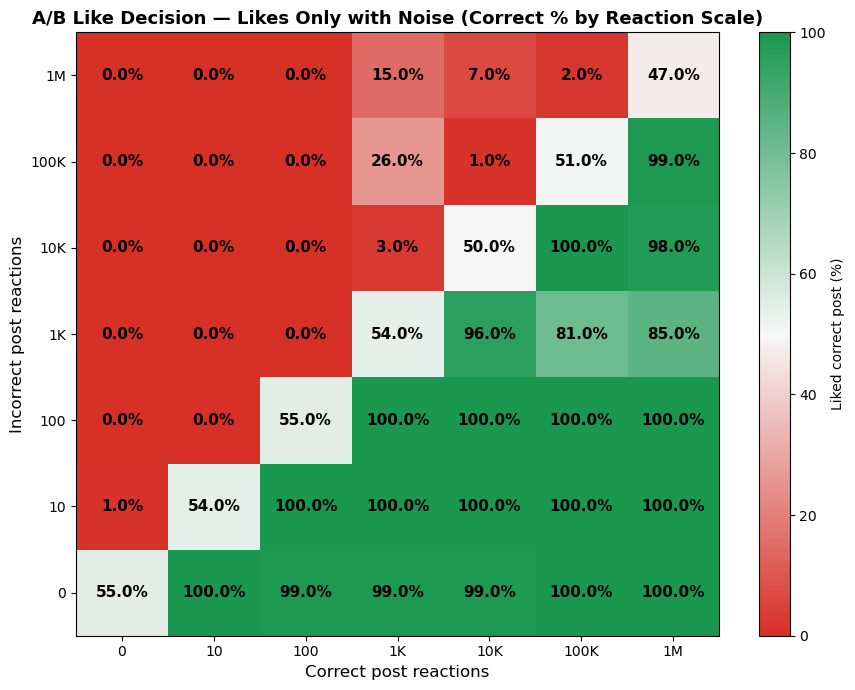

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_results_likes_only_noise_paired_grid.png


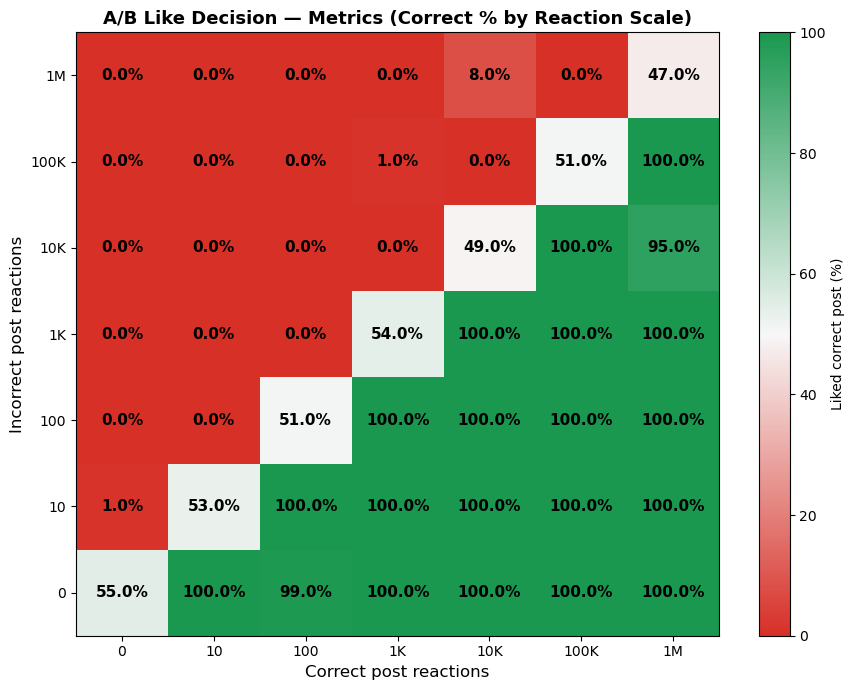

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_results_metrics_paired_grid.png


In [44]:
import e1_utils.e1_analysis_optimized as e1
import importlib
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
#plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
#             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



In [ ]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.


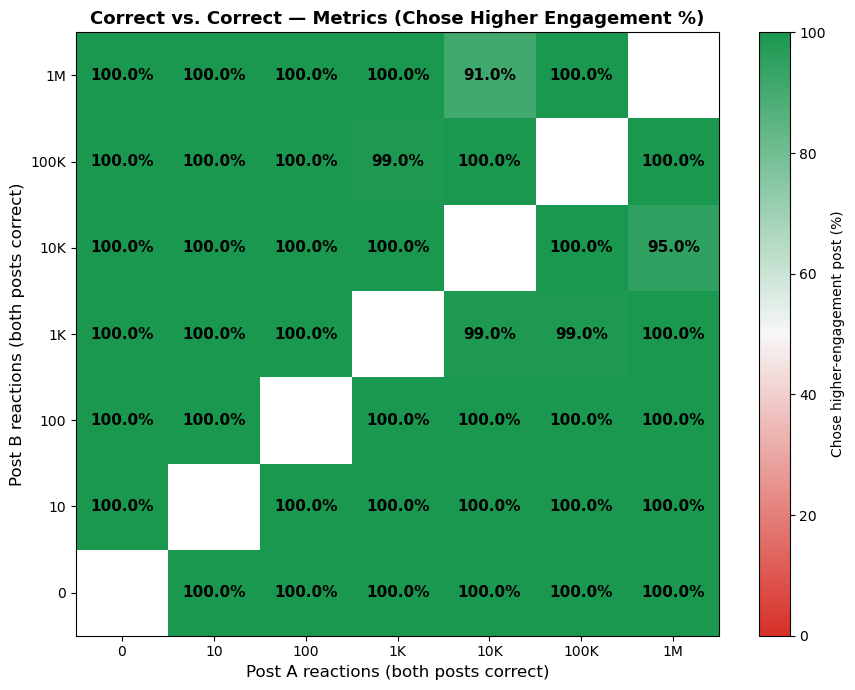

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_results_metrics_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


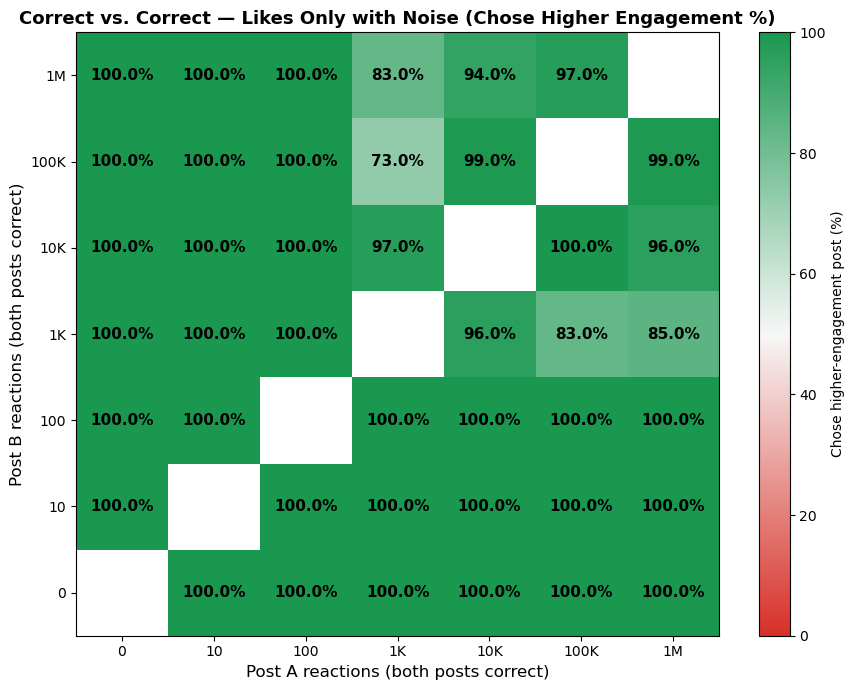

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/gemma4-e4b/outputs/e1_results_likes_only_noise_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


In [43]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_cc_grid

# Correct vs. correct control — Metrics (realistic)
plot_cc_grid(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Metrics (Chose Higher Engagement %)")

# Correct vs. correct control — Likes only with noise
plot_cc_grid(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Likes Only with Noise (Chose Higher Engagement %)")


## Two-step prompt pilot (supervisor item, 2026-08)

Tests whether making the model verify factual correctness explicitly *before* the popularity-influenced like/scroll decision improves the diagonal (competence, disparity=0). Two designs run head-to-head, diagonal cells only (7 scales x 100 images = 700 trials each, not the full 49-cell grid -- this is specifically about the diagonal, see `experiments/e1/e1_utils/e1_two_step.py` module docstring for the full rationale and why the grid is narrowed here). Compare each design's `e1_results_metrics_diagonal_twostep_*.json` diagonal accuracy against this notebook's existing single-step `e1_results_metrics_paired.json` diagonal accuracy (Section further up).

Currently pointed at the same `metrics_simple_plot_bigfont` images already used elsewhere in this notebook. If/when the font-size-adjusted ("bigfont") images are composited into full posts, swap `correct_base`/`incorrect_base` below for that directory instead.

In [ ]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="paired_verdict", output_filename="e1_results_metrics_diagonal_twostep_paired_verdict.json",
                               inference_fn=run_inference_gemma,
                               baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                               baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")

In [ ]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="isolated_verdict", output_filename="e1_results_metrics_diagonal_twostep_isolated_verdict.json",
                               inference_fn=run_inference_gemma,
                               baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                               baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")

In [ ]:
import json

def diagonal_accuracy(path, filter_diagonal=False):
    records = json.loads((OUTPUT_DIR / path).read_text())
    if filter_diagonal:
        records = [r for r in records if r["correct_scale"] == r["incorrect_scale"]]
    return 100 * sum(r["liked_variant"] == "correct" for r in records) / len(records), len(records)

single_pct, single_n = diagonal_accuracy("e1_results_metrics_paired.json", filter_diagonal=True)
paired_pct, paired_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_paired_verdict.json")
isolated_pct, isolated_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_isolated_verdict.json")

print(f"Single-step (existing, diagonal cells only): {single_pct:.1f}%  (n={single_n})")
print(f"Two-step, paired_verdict:                    {paired_pct:.1f}%  (n={paired_n})")
print(f"Two-step, isolated_verdict:                  {isolated_pct:.1f}%  (n={isolated_n})")